In [1]:
import torch # This is PyTorch

# First need to verify this session is actually running on a GPU before doing any training
# Part of the per- ession warm up. if CUDA shows False then the runtime type needs changing to T4 GPU

print("PyTorch version:", torch.__version__)

print("CUDA available:", torch.cuda.is_available()) # CUDA is NVIDIA's system for running code on their GPUs so need this to be True.

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none") # this asks GPU number 0 its name. Need it to be Tesla T4

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Mount Google Drive so the dataset zip on it is reachable from my machine
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Confirm the project folder on Drive is visible from Colab
!ls /content/drive/MyDrive/ai-music-detector/data

spectrograms.zip  test.csv  valid.csv


In [4]:
# Copy the dataset zip from Drive onto this machines fast local disk and extract it.
# Training reads thousands of small files so its too slow over the Drive mount which is why I'm doing it this way
# This cell is part of the per session warm up (as local disk is wiped between sessions).

!cp /content/drive/MyDrive/ai-music-detector/data/spectrograms.zip /content/ # cp = copy: <source on Drive> <destination on local disk>

!unzip -q -o /content/spectrograms.zip -d /content/  # -q = quiet (no perfile output). -o = overwrite without asking. -d = destination folder

!ls /content/spectrograms | head -5  # ls = list folder contents. | pipes it into head -5 = show first 5 lines only

fake_00014_suno_1.npy
fake_00036_suno_0.npy
fake_00053_suno_1.npy
fake_00057_suno_1.npy
fake_00062_udio_1.npy


In [5]:
from pathlib import Path

# Build a full inventory of the extracted spectrograms to verify nothing  was lost. Expecting 3722 files (2000 fake and 1722 real) to match what was generated locally.

# Build a sorted list of every spectrogram file on the local disk
DATA_DIR = Path("/content/spectrograms")

all_files = sorted(DATA_DIR.glob("*.npy"))

# The label lives in the filename real_ or fake_ so the list can be split by checking how each filename starts
real_files = [f for f in all_files if f.name.startswith("real")]

fake_files = [f for f in all_files if f.name.startswith("fake")]

print("Total:", len(all_files))

print("Real:", len(real_files))

print("Fake:", len(fake_files))

Total: 3722
Real: 1722
Fake: 2000


Shape: (128, 469)
Dtype: float32
Value range: -80.0 to 0.0


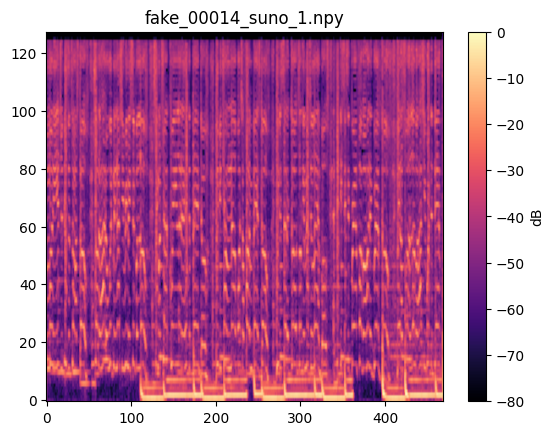

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load one spectrogram and inspect exactly what the CNN will be fed
sample = np.load(all_files[0])

print("Shape:", sample.shape) # Shape = (mel bands, time frames). This is the 2D grid the CNN will see as an image

print("Dtype:", sample.dtype) # Dtype = the number type stored in the array. Expecting float32 which is also what PyTorch uses natively

print("Value range:", sample.min(), "to", sample.max()) # Value range is the dB-scaled mel values so roughly -80 (silence) up to 0 (loudest). Needed later when deciding how to normalise inputs.

# Draw the array as an image to confirm it still looks like real music.
# Each cell is coloured by its energy value (dark = quiet and bright = loud)
plt.imshow(sample, aspect="auto", origin="lower", cmap="magma") # aspec = "auto" stretches it to a readable rectangle and origin = "lower" puts low frequencies at the bottom (this is spectrogram convention)

plt.colorbar(label="dB")

plt.title(all_files[0].name)

plt.show()

In [7]:
import librosa

# Checking for the sample rate confound from the baseline investigation
# preprocess.py loaded audio at librosa's default 22050Hz (not the sr = 16000 fix from baseline.py)
# so this means that the fakes (16kHz sources = nothing above 8kHz) may have an empty strip at the top of every
# spectrogram that the reals (48/24kHz sources) dont have. A CNN would learn that instead of timbre.

# this work out which mel bands sit above 8000Hz (the fakes ceiling)
band_freqs = librosa.mel_frequencies(n_mels=128, fmax=22050 / 2) # centre frequency of each of the 128 bands

top_bands = band_freqs > 8000 # boolean mask with True for bands above 8kHz

print("Bands above 8kHz:", top_bands.sum())

# mean energy in those top bands for a sample of each class (100 files each)
real_top = [np.load(f)[top_bands].mean() for f in real_files[:100]]

fake_top = [np.load(f)[top_bands].mean() for f in fake_files[:100]]

print("Real top-band mean dB:", round(np.mean(real_top), 1))

print("Fake top-band mean dB:", round(np.mean(fake_top), 1))

Bands above 8kHz: 12
Real top-band mean dB: -54.0
Fake top-band mean dB: -56.6


Confound check for before and after the fix. First run of this check (spectrograms generated at librosa's default 22050Hz): Real top band mean was -56.5 dB, Fake was -80.0 dB. The fakes were pinned at the exact silence floor meaning a completely empty strip above 8kHz in every fake that a CNN would learn instead of timbre.

After adding sr = 16000 to preprocess.py (matching baseline.py) and regenerating all 3722 spectrograms: Real was -54.0 and Fake was -56.6 so both classes populated with no strip. This means the confound is gone.

This cells band maths (fmax = 22050/2) describes the old layout. On the regenerated data it simply compares the top 12 rows which is where the strip was so the check still does its job.

In [8]:
import pandas as pd

# Load the train/val/test split file straight from the GitHub repo (it is public so no login needed).
# The CNN must use the exact same split as the baseline so the comparison between the models is fair.
# This CSV holds the full 4000 track plan including the 278 tracks that never made it to spectrograms.
SPLITS_URL = "https://raw.githubusercontent.com/cianbond/ai-music-detector/main/data/subset_splits.csv"

splits = pd.read_csv(SPLITS_URL)

print(splits[["filename", "split", "target"]].head()) # just the three columns the CNN needs

print()

print(splits["split"].value_counts()) # expecting the raw plan counts of train 3203, val 403 and test 394

            filename  split  target
0  fake_44156_udio_1  train       1
1  fake_51867_suno_1  train       1
2  fake_47674_suno_0  train       1
3  fake_51554_suno_0  train       1
4  fake_18467_udio_0  train       1

split
train    3203
val       403
test      394
Name: count, dtype: int64


In [9]:
# Match the 4000 track plan against the 3722 spectrograms actually on disk.
# Tracks which files never made it (the 277 missing and 1 too short) and drop them. this leaves the exact same working split the baseline used.

# build the full path where each tracks spectrogram should be (filename column has no extension)
splits["path"] = [DATA_DIR / (name + ".npy") for name in splits["filename"]]

# check which of those files really exist on disk (True or False per row)
splits["exists"] = [p.exists() for p in splits["path"]]

# keep only the rows where the file exists and renumber the rows from 0
working = splits[splits["exists"]].reset_index(drop=True)

print("Working total:", len(working)) # expecting 3722

print()

print(working["split"].value_counts()) # expecting train 2969, val 383 and test 370

Working total: 3722

split
train    2969
val       383
test      370
Name: count, dtype: int64


In [10]:
import torch
from torch.utils.data import Dataset

class SpectrogramDataset(Dataset):
    """Feeds spectrograms and labels to the model one at a time.
       Gets given a table of tracks (path + target) and loads each
       file from disk only at the moment its asked for."""

    def __init__(self, table):

        # store the file paths and labels as plain lists (the catalogue)
        self.paths = list(table["path"])

        self.labels = list(table["target"])

    def __len__(self):

        return len(self.paths) # how many items the dataset has

    def __getitem__(self, i):

        # load spectrogram number i from disk (only now. not up front)
        spec = np.load(self.paths[i])

        # convert numpy array to tensor (exact same numbers but GPU ready)
        spec = torch.from_numpy(spec)

        # add the channel dimension the CNN expects. (128, 469) now becomes (1, 128, 469)
        spec = spec.unsqueeze(0)

        # convert the label to a tensor too (float because the loss function will want that)
        label = torch.tensor(self.labels[i], dtype=torch.float32)

        return spec, label

# one dataset per split (all three share the same class and the same table format)
train_ds = SpectrogramDataset(working[working["split"] == "train"])

val_ds   = SpectrogramDataset(working[working["split"] == "val"])

test_ds  = SpectrogramDataset(working[working["split"] == "test"])

print("Datasets:", len(train_ds), len(val_ds), len(test_ds)) # expecting 2969, 383 and 370

# fetch one item as a test of __getitem__
spec, label = train_ds[0] # this is the first row as the index is 0

print("One item:", spec.shape, spec.dtype, "label:", label) # expecting torch.Size([1, 128, 469]) and a 1.0 (first train row is a fake)

Datasets: 2969 383 370
One item: torch.Size([1, 128, 469]) torch.float32 label: tensor(1.)


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32 # how many spectrograms the model sees at once. using small amounts at a time so it doesn't get overloaded and is GPU efficient

# training loader: shuffle=True so the order is reshuffled every epoch. This is to stop the model from learning track order
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# val and test loaders: shuffle=False
# No learning happens here so order doesnt matter and also steady order is easier to compare.
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# grab one batch to see the shape the model will actually receive
specs, labels = next(iter(train_loader))

print("Batch of specs:", specs.shape)  # expecting torch.Size([32, 1, 128, 469])

print("Batch of labels:", labels.shape) # expecting torch.Size([32])

print("Batches per epoch:", len(train_loader)) # expecting 93 (2969 / 32 rounded up)

Batch of specs: torch.Size([32, 1, 128, 469])
Batch of labels: torch.Size([32])
Batches per epoch: 93


In [12]:
import random

# Fix every source of randomness so the final training run is reproducible.
# Without this each run starts from different random weights and a different shuffle order so the numbers come out slightly different every time.
SEED = 42

random.seed(SEED)          # pythons own random generator

np.random.seed(SEED)       # numpys generator

torch.manual_seed(SEED)    # pytorchs generator (covers the CPU and the GPU)

# make the GPUs conv operations pick the same algorithm every time (strict mode)
torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False

print("Seed set:", SEED)

Seed set: 42


In [13]:
import torch.nn as nn
from torchvision import models

# Load ResNet18 which is already trained on ImageNet (millions of photos).
# it already knows how to see things on pictures (edges, textures, shapes etc.).
#  Reuse all of that here and only retrain the final decision for our real vs fake question.
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze every pretrained layer so training does not change them.
# They already see well. Only the layers that are swapped in below will learn.
for param in model.parameters():
    param.requires_grad = False

# Front edge: ResNet expects 3 channel colour photos but the spectrograms only have 1 channel
# so replace the first conv layer with a 1 channel version.
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False) # swap ResNet's 3 channel first layer for a 1 channel one (our spectrograms have 1 channel not RGB). 64 filters and 7x7 window.

# Back edge: ResNet ends in a 1000 class layer (ImageNet). Replace it with
# a fresh layer giving a single output (one number = real or fake).
model.fc = nn.Linear(model.fc.in_features, 1)

# quick look at the two layers we changed
print("First layer:", model.conv1)
print("Last layer:", model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]

First layer: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Last layer: Linear(in_features=512, out_features=1, bias=True)


In [14]:
# Move the model onto the GPU (the T4) so training runs on the graphics card and not the CPU.
# "cuda" = the GPU "cpu" = the fallback. Have picked the T4 at the start for this.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device) # relocate every weight in the model onto that device

print("Model is on:", device)

# confirm by checking where one layers weights actually live
print("Example weight device:", next(model.parameters()).device)

Model is on: cuda
Example weight device: cuda:0


In [15]:
# Thse below are the two tools that make the learning happen

# Loss function: this is the scorer. Measures how wrong each guess is (one number).
# BCEWithLogitsLoss is the standard choice for a yes/no (binary) question with a single raw output which is exactly like the real vs fake setup is here.
criterion = nn.BCEWithLogitsLoss()

# Optimiser. This is the adjuster. Nudges the weights to reduce the loss.
# Pass only the parameters that require gradients (the two unfrozen layers at the front and back) so it never tries to change the frozen ResNet body.
optimizer = torch.optim.Adam(

    [p for p in model.parameters() if p.requires_grad],

    lr=0.001

)

# confirm how many parameter groups the optimiser is actually training
trainable = [p for p in model.parameters() if p.requires_grad]

print("Trainable parameter tensors:", len(trainable))

print("Frozen + trainable total:", len(list(model.parameters())))

Trainable parameter tensors: 3
Frozen + trainable total: 62


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Runs one full pass through the training data (one epoch).
       The model guesses each batch, gets scored and the two unfrozen
       layers get nudged to be less wrong. Then it returns the average loss."""

    model.train() # put the model in training mode (learning on)

    running_loss = 0.0 # adds up the loss over all the batches so it can be averaged at the end

    for specs, labels in loader: # one batch of 32 at a time (93 batches per epoch)

        # move the batch onto the GPU where the model lives (model and data must be on the same device)
        specs = specs.to(device)

        labels = labels.to(device)

        # clear the leftover gradients from the previous batch (otherwise they all accumulate and corrupt training)
        optimizer.zero_grad()

        # Forward pass: the model makes its guesses for the whole batch
        outputs = model(specs).squeeze(1) # model gives (32, 1) so squeeze it down to (32) to match the labels shape

        # Score: how wrong were the 32 guesses (one number for the whole batch)
        loss = criterion(outputs, labels)

        # Backward pass: work out which direction each trainable weight should move to be less wrong
        loss.backward()

        # Nudge: the optimiser actually updates the weights by a small step. this is where the learning happens
        optimizer.step()

        running_loss += loss.item() # .item() pulls the plain number out of the loss tensor

    return running_loss / len(loader) # this gives the average loss across all of the batches

In [17]:
def evaluate(model, loader, device):
    """Runs the model over a dataset without any learning (this is like a mock exam).
       Counts how many tracks it gets right and then returns the accuracy."""

    model.eval() # put the model in evaluation mode (the partner of model.train)

    correct = 0 # tally of right answers
    total = 0   # tally of tracks seen

    with torch.no_grad(): # no learning here so switch off the history tracking as this is faster and saves memory

        for specs, labels in loader:

            # same device rule as training: the batch joins the model on the GPU
            specs = specs.to(device)

            labels = labels.to(device)

            # forward pass only (guesses but no scoring for learning and no nudging)
            outputs = model(specs).squeeze(1)

            # turn raw confidences into verdicts: positive logit means fake (1) and negative means real (0)
            preds = (outputs > 0).float()

            # count how many verdicts match the truth in this batch
            correct += (preds == labels).sum().item()

            total += labels.size(0) # add this batchs size to the running total (last batch may be smaller than 32)

    return correct / total # accuracy as a fraction (e.g. 0.94 means 94% right)

In [18]:
import copy

EPOCHS = 10 # have gone for 10 this time instead of in a previous one to allow more time to let the val wobble settle

# training run: train then have a go on val set 10 times over and every
# time the val accuracy beats the best so far it keeps a snapshot of the models weights.
# At the end the best snapshot is loaded back so the model kept is the best one and not just whichever epoch happened to be last.
best_val_acc = 0.0

best_state = None

history = {"train_loss": [], "val_acc": []} # record the curves per epoch (for the report figures later)

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device) # one full training run (93 batches of guess, score and nudge). returns the average loss

    val_acc = evaluate(model, val_loader, device) # the result on the 383 val tracks (no learning). returns the accuracy

    history["train_loss"].append(train_loss) # add this epochs loss to the curve record

    history["val_acc"].append(val_acc) # and this epochs accuracy (both for report figures later)

    marker = ""

    if val_acc > best_val_acc: # did it beat the current best

        best_val_acc = val_acc # update the record to beat

        best_state = copy.deepcopy(model.state_dict()) # snapshot the weights (a full independent copy)

        marker = "  <- new best (snapshot kept)" # tag this epochs report card line

    print(f"Epoch {epoch + 1}/{EPOCHS}  train loss: {train_loss:.4f}  val accuracy: {val_acc:.4f}{marker}")

# restore the best snapshot so the model in memory is the best version

model.load_state_dict(best_state) # puts the best epochs weights back into the model (overwrites wherever epoch 10 ended)

print(f"Best model loaded back (val accuracy {best_val_acc:.4f})")

Epoch 1/10  train loss: 0.3277  val accuracy: 0.9687  <- new best (snapshot kept)
Epoch 2/10  train loss: 0.0847  val accuracy: 0.9843  <- new best (snapshot kept)
Epoch 3/10  train loss: 0.0475  val accuracy: 0.8277
Epoch 4/10  train loss: 0.0292  val accuracy: 0.9765
Epoch 5/10  train loss: 0.0264  val accuracy: 0.9713
Epoch 6/10  train loss: 0.0223  val accuracy: 0.9922  <- new best (snapshot kept)
Epoch 7/10  train loss: 0.0183  val accuracy: 0.9269
Epoch 8/10  train loss: 0.0152  val accuracy: 0.9817
Epoch 9/10  train loss: 0.0100  val accuracy: 0.9948  <- new best (snapshot kept)
Epoch 10/10  train loss: 0.0110  val accuracy: 0.9922
Best model loaded back (val accuracy 0.9948)


In [19]:
# The Test. this is the 370 test tracks the model has never seen in any way.
# Just run once only. this number is the CNNs official result for the report (FR-005)
test_acc = evaluate(model, test_loader, device)

print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9973


In [20]:
# Save the trained models weights to Drive so this exact model survives the session.
# state_dict is the models weights in file form. Drive is permanent unlike this machines disk.
MODEL_PATH = "/content/drive/MyDrive/ai-music-detector/cnn_resnet18_best.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Saved to:", MODEL_PATH)

!ls -lh /content/drive/MyDrive/ai-music-detector/ # confirm its there and check the file size

Saved to: /content/drive/MyDrive/ai-music-detector/cnn_resnet18_best.pth
total 43M
-rw------- 1 root root  319 Jun 22 21:10 check_setup.py
-rw------- 1 root root  43M Jul 17 15:13 cnn_resnet18_best.pth
drwx------ 3 root root 4.0K Jun 22 21:10 data
-rw------- 1 root root  511 Jun 22 21:10 download_metadata.py
-rw------- 1 root root  18K Jun 22 21:10 explore_data.ipynb


In [21]:
def get_predictions(model, loader, device):
    """Runs the model over a dataset with no learning and hands back two plain lists: every verdict it gave and every true label in matching order.
       This is the raw material for the confusion matrix and the mistake hunt."""

    model.eval() # evaluation mode as always when not training

    # make 2 lists for all of the results. one for predictions and one for labels
    all_preds = []

    all_labels = []

    with torch.no_grad(): # no learning as just checking things here so no history tracking needed

        for specs, labels in loader:

            specs = specs.to(device) # batch joins the model on the GPU

            outputs = model(specs).squeeze(1) # raw logits for the batch

            preds = (outputs > 0).float() # logits to verdicts at the zero fence

            all_preds.extend(preds.cpu().tolist())  # bring off the GPU and turn into plain numbers

            all_labels.extend(labels.tolist()) # labels stayed on the cpu so straight to a list

    return all_preds, all_labels

# collect the test sets verdicts and truths (no learning happens so this is safe to rerun)
test_preds, test_labels = get_predictions(model, test_loader, device)

print("Preds:", len(test_preds), " Labels:", len(test_labels), " Match:", len(test_preds) == len(test_labels)) # both should be 370 and Match should be True

Preds: 370  Labels: 370  Match: True


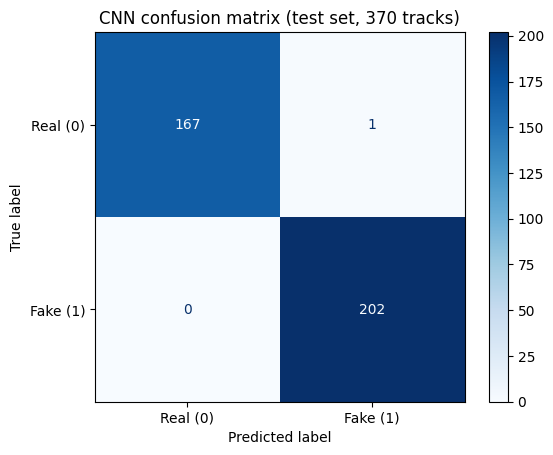

Correct real (TN): 167
Real called fake (FP): 1
Fake called real (FN): 0
Correct fake (TP): 202


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build the confusion matrix from the 370 collected verdicts and truths. It splits the results into the four boxes so what kind of right and wrong can be seen and
# not just the overall accuracy. (same tool the baseline notebook used so the two are comparable)

cm = confusion_matrix(test_labels, test_preds) # count the four boxes (truths first, guesses second: the sklearn order)

# show it as a labelled grid
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"]) # prepare the drawing to be drawn below with readable class names

disp.plot(cmap="Blues") # draw it out shading cells by count (big = dark and small = pale)

plt.title("CNN confusion matrix (test set, 370 tracks)")

plt.show()

# also print the four numbers plainly
tn, fp, fn, tp = cm.ravel() # unpack the grid into its four values

print(f"Correct real (TN): {tn}") # truth real. guessed real. true negative

print(f"Real called fake (FP): {fp}")  # truth real. guessed fake. false positive

print(f"Fake called real (FN): {fn}") # truth fake. guessed real. false negative

print(f"Correct fake (TP): {tp}") # truth fake. guessed fake. true positive

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score # standard classification metrics beyond raw accuracy

# Precision, recall and F1 give a fuller picture than accuracy alone especially the difference between the two error types (false alarms vs missed fakes).
# "Positive" here means flagged as fake (class 1).
precision = precision_score(test_labels, test_preds) # of all the tracks it called fake, how many really were

recall = recall_score(test_labels, test_preds)       # of all the tracks that were fake, how many it caught

f1 = f1_score(test_labels, test_preds)               # F1 score is the balance of the precision and recall (their harmonic mean)

print(f"Precision: {precision:.4f}") # only the 1 false positive (a real called fake) pulls this below 1

print(f"Recall:    {recall:.4f}")    # no fakes were missed (0 false negatives) so this is exactly 1

print(f"F1 score:  {f1:.4f}")        # single combined score which sits between precision and recall

Precision: 0.9951
Recall:    1.0000
F1 score:  0.9975


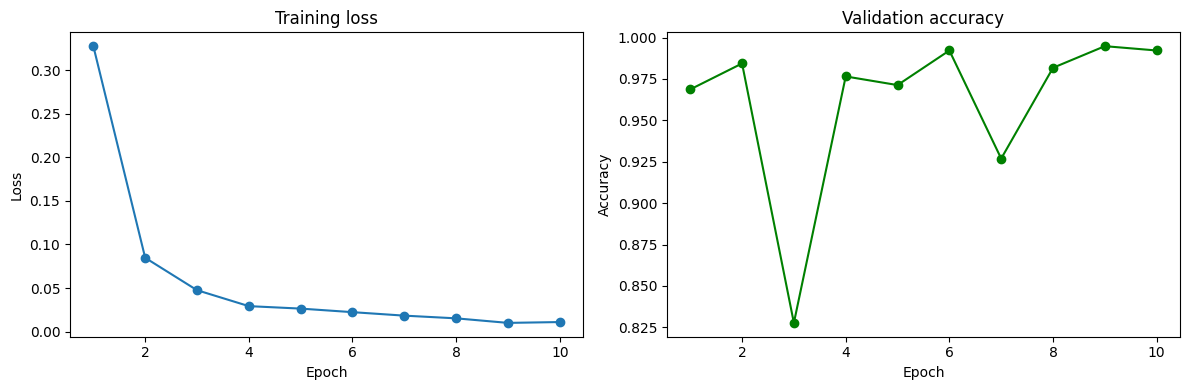

In [24]:
import matplotlib.pyplot as plt

# Plot the training curves recorded during training (one point per epoch).
# Left: training loss should fall.
# Right: val accuracy should climb (with the wobble that was observed).
# This evaluation figure shows the model genuinely learned.
epochs = range(1, len(history["train_loss"]) + 1) # x-axis: epoch numbers 1 to 10

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) # one figure. two side-by-side plots

# left plot: training loss per epoch
ax1.plot(epochs, history["train_loss"], marker="o")

ax1.set_title("Training loss")

ax1.set_xlabel("Epoch")

ax1.set_ylabel("Loss")

# right plot: validation accuracy per epoch
ax2.plot(epochs, history["val_acc"], marker="o", color="green")

ax2.set_title("Validation accuracy")

ax2.set_xlabel("Epoch")

ax2.set_ylabel("Accuracy")

plt.tight_layout() # stop the two plots overlapping

plt.show()

In [25]:
import numpy as np

# Find which test track the model got wrong (the single false positive from the confusion matrix).
# The verdict lists are just 1s and 0s so they dont carry filenames. To recover which track it was rebuild the test table in the same order the loader served it then find the mismatching row.

test_rows = working[working["split"] == "test"].reset_index(drop=True) # the 370 test tracks in the same order as test_loader

preds_arr = np.array(test_preds)   # verdicts as an array so they can be compared elementwise

labels_arr = np.array(test_labels) # truths as an array

wrong_positions = np.where(preds_arr != labels_arr)[0] # positions where verdict and truth disagree

print("Number wrong:", len(wrong_positions)) # should be just 1

for pos in wrong_positions:

    row = test_rows.iloc[pos] # the track at that position in the test table

    print(f"\nPosition {pos}: {row['filename']}")

    print(f"  True label: {int(labels_arr[pos])} (0=real)  Model said: {int(preds_arr[pos])} (1=fake)")

    print(f"  Source: {row['source']}  Split: {row['split']}")

Number wrong: 1

Position 234: real_03580
  True label: 0 (0=real)  Model said: 1 (1=fake)
  Source: nan  Split: test


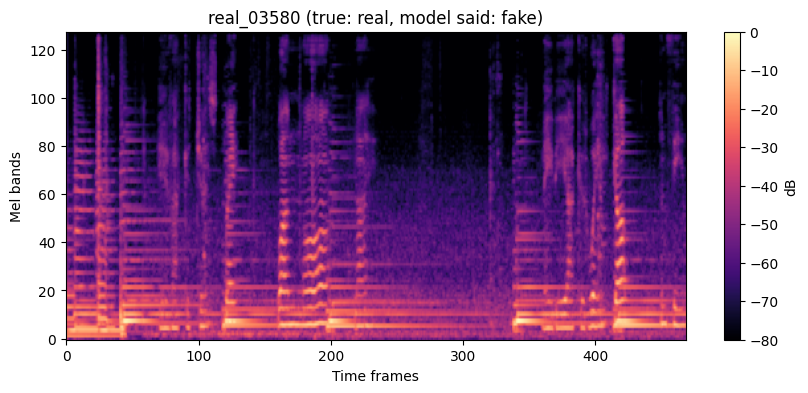

Label check: 0.0 (0 = real, so this is the right item)


In [26]:
import matplotlib.pyplot as plt

# View the spectrogram of the one real track the model wrongly called fake.
# Pulling it through the loaders dataset means I can see the exact same array the model saw (same file and same loading steps) so I'm judging the same evidence the model judged.

spec, label = test_loader.dataset[234] # item 234 of the test set: the culprit and its true label

spec = spec.squeeze(0).numpy() # drop the channel dimension: (1, 128, 469) becomes (128, 469) for plotting

plt.figure(figsize=(10, 4))

plt.imshow(spec, aspect="auto", origin="lower", cmap="magma") # origin lower puts low frequencies at the bottom (how spectrograms read)

plt.colorbar(label="dB")

plt.title("real_03580 (true: real, model said: fake)")

plt.xlabel("Time frames")

plt.ylabel("Mel bands")

plt.show()

print("Label check:", float(label), "(0 = real, so this is the right item)") # sanity check that position 234 really is a real track